# 🚢 Titanic ML — Full Pipeline & RandomForest Baseline

**Competition:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic)  
**Goal:** Predict which passengers survived the Titanic shipwreck.  
**Metric:** Binary classification accuracy on the test set.

---

> **Kernel:** Make sure you have selected the `Python (titanic-ml)` kernel before running any cells.
> In VS Code, click the kernel selector in the top-right corner of this notebook.

## 0. ⚙️ Setup & Imports

We import all the required libraries, configure our local path environment, and load our custom `src/` modules.

In [23]:
import os
import sys

# Insert project root to path so we can import src modules
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.helpers import load_data, save_submission, display_info, set_seed
from src.preprocessing import clean
from src.features import engineer, select_features
from src.model import build_baseline_model, train_model, predict, cross_validate_model, save_model
from src.evaluate import (
    accuracy_score,
    print_classification_report,
    plot_confusion_matrix,
    plot_feature_importance,
    compare_models,
    roc_auc
)

set_seed(42)
%matplotlib inline

[seed] Random seed set to 42


## 1. 📂 Load Data

We load the train and test CSV datasets using our helper function.

In [24]:
train_raw = load_data("../data/train.csv")
test_raw = load_data("../data/test.csv")

print(f"Train raw shape: {train_raw.shape}")
print(f"Test raw shape: {test_raw.shape}")

display_info(train_raw, "Train Raw Data")

FileNotFoundError: [Errno 2] No such file or directory: '../data/train.csv'

## 2. 📊 Exploratory Data Analysis (EDA)

Let's visualize the survival rates across several demographic features to understand key patterns in the dataset.

C:\Users\USER\AppData\Local\Temp\ipykernel_5360\205029072.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=train_raw, palette="Blues_d")


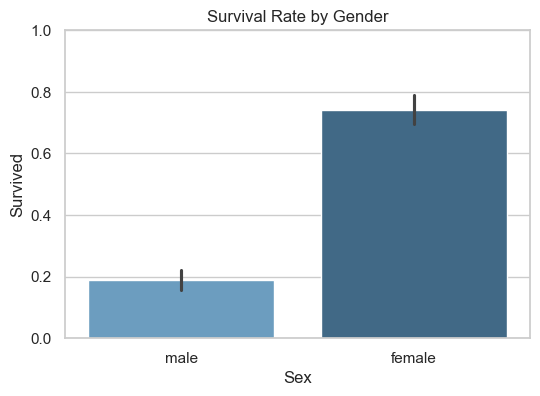

In [3]:
# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)

# 1. Survival rate by Sex
plt.figure()
sns.barplot(x="Sex", y="Survived", data=train_raw, palette="Blues_d")
plt.title("Survival Rate by Gender")
plt.ylim(0, 1)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_5360\2269949435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=train_raw, palette="Purples_d")


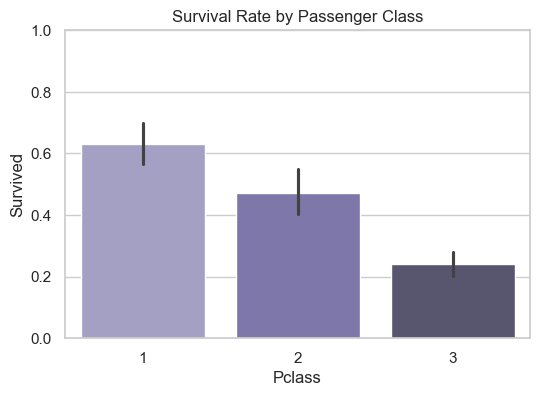

In [4]:
# 2. Survival rate by Passenger Class (Pclass)
plt.figure()
sns.barplot(x="Pclass", y="Survived", data=train_raw, palette="Purples_d")
plt.title("Survival Rate by Passenger Class")
plt.ylim(0, 1)
plt.show()

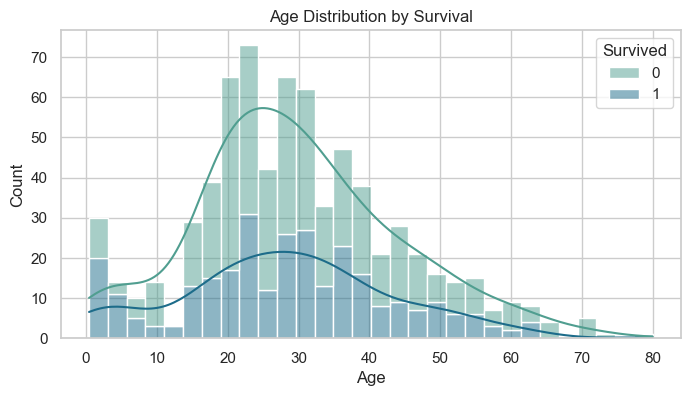

In [5]:
# 3. Age distribution of survivors vs non-survivors
plt.figure(figsize=(8, 4))
sns.histplot(x="Age", hue="Survived", data=train_raw, multiple="stack", kde=True, bins=30, palette="crest")
plt.title("Age Distribution by Survival")
plt.show()

## 3. 🧼 Data Preprocessing

We clean the data, fill missing values (imputing Age using the median grouped by Class and Sex, filling Embarked with the mode, and Fare with the median), and drop columns like Cabin, Ticket, and Name.

In [20]:
print("Missing values in Train before preprocessing:")
print(train_raw.isnull().sum())

# We run feature engineering's engineer() first because it extracts Title from Name, and clean() drops Name!
train_fe = engineer(train_raw.copy())
test_fe = engineer(test_raw.copy())

train_clean = clean(train_fe)
test_clean = clean(test_fe)

print("\nMissing values in Train after preprocessing:")
print(train_clean.isnull().sum())
print(f"\nTrain clean shape: {train_clean.shape}")

Missing values in Train before preprocessing:


NameError: name 'train_raw' is not defined

## 4. 🛠️ Feature Engineering & Selection

We select the best engineered features (such as `Title`, `FamilySize`, `IsAlone`, `AgeBand`, `FareBand`) to use in our ML models.

In [7]:
print("Columns in cleaned DataFrame:")
print(train_clean.columns.tolist())

feature_cols = select_features(train_clean)
print(f"\nSelected features ({len(feature_cols)}): {feature_cols}")

X_train = train_clean[feature_cols]
y_train = train_clean["Survived"]
X_test = test_clean[feature_cols]

Columns in cleaned DataFrame:
['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Title', 'FamilySize', 'IsAlone', 'FareBand', 'AgeBand', 'Embarked_Q', 'Embarked_S']

Selected features (11): ['Pclass', 'Sex', 'AgeBand', 'FareBand', 'FamilySize', 'IsAlone', 'Title', 'Embarked_Q', 'Embarked_S', 'SibSp', 'Parch']


## 5. 🌲 Baseline Model Training

We build and cross-validate our baseline Random Forest classifier.

In [8]:
print("Building and training baseline Random Forest model...")
rf_model = build_baseline_model("random_forest")
rf_cv = cross_validate_model(rf_model, X_train, y_train, cv=5)

# Fit model on the full training set
rf_model = train_model(rf_model, X_train, y_train)

Building and training baseline Random Forest model...


  CV 5-fold accuracy: 0.8305 ± 0.0073
  Individual folds: ['0.8268', '0.8202', '0.8315', '0.8315', '0.8427']


## 6. 📈 Model Evaluation

We evaluate the Random Forest model on the training set using multiple diagnostic tools (confusion matrix, feature importances, ROC curve, and classification report).

In [9]:
y_train_pred = predict(rf_model, X_train)
print("Training Set Performance:")
accuracy_score(y_train, y_train_pred)

print_classification_report(y_train, y_train_pred)

Training Set Performance:
  Accuracy : 0.8361  (83.61%)

  Classification Report:
                   precision    recall  f1-score   support
  
  Did not survive       0.85      0.90      0.87       549
         Survived       0.82      0.74      0.78       342
  
         accuracy                           0.84       891
        macro avg       0.83      0.82      0.82       891
     weighted avg       0.84      0.84      0.83       891
  


Plotting Confusion Matrix...


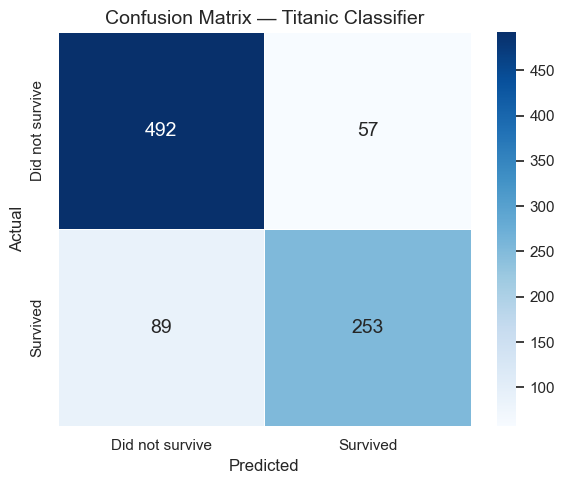

In [10]:
print("Plotting Confusion Matrix...")
plot_confusion_matrix(y_train, y_train_pred, save=False)

Plotting Feature Importances...


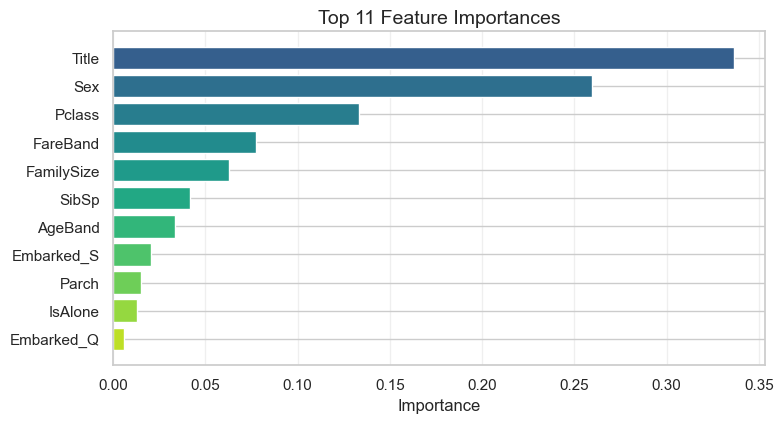

In [11]:
print("Plotting Feature Importances...")
plot_feature_importance(rf_model, feature_cols, top_n=len(feature_cols), save=False)

Plotting ROC Curve...


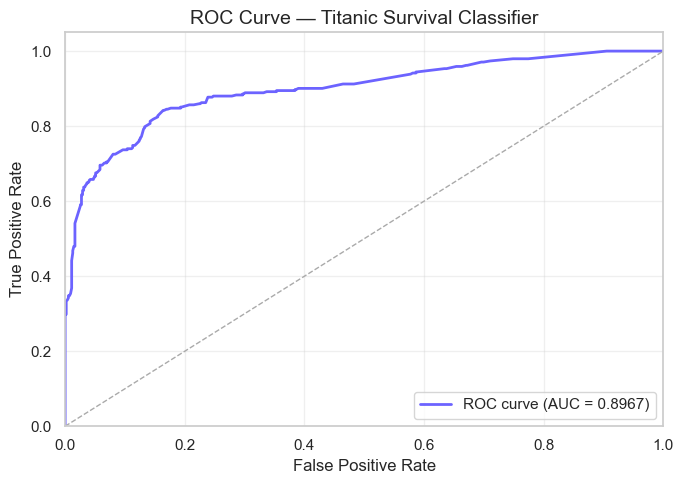

  ROC-AUC  : 0.8967


In [12]:
if hasattr(rf_model, "predict_proba"):
    y_prob = rf_model.predict_proba(X_train)[:, 1]
    print("Plotting ROC Curve...")
    roc_auc(y_train, y_prob, save=False)

## 7. ⚖️ Model Comparison

Let's compare the performance of four different algorithms using 5-fold stratified cross-validation:
1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. XGBoost


-- Logistic Regression --
  CV 5-fold accuracy: 0.8036 ± 0.0082
  Individual folds: ['0.7877', '0.8090', '0.8034', '0.8090', '0.8090']

-- Random Forest --


  CV 5-fold accuracy: 0.8305 ± 0.0073
  Individual folds: ['0.8268', '0.8202', '0.8315', '0.8315', '0.8427']

-- Gradient Boosting --


  CV 5-fold accuracy: 0.8148 ± 0.0093
  Individual folds: ['0.8101', '0.8090', '0.8034', '0.8258', '0.8258']

-- Xgboost --


  CV 5-fold accuracy: 0.8272 ± 0.0087
  Individual folds: ['0.8156', '0.8371', '0.8202', '0.8371', '0.8258']

Plotting Model Comparison...


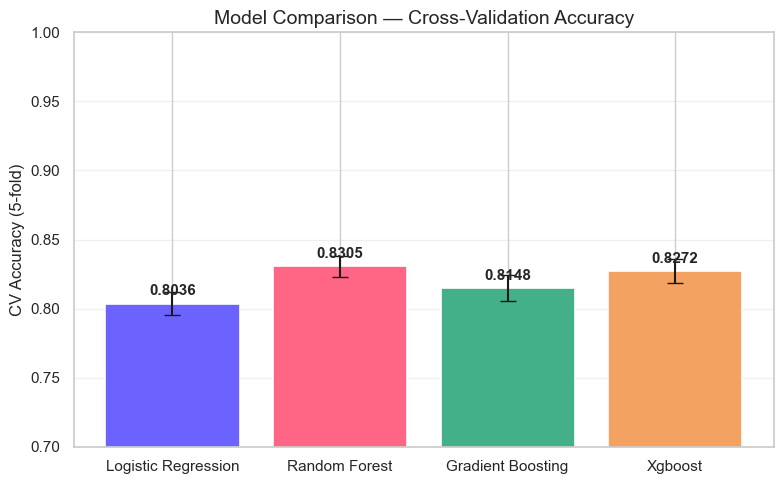

In [13]:
models_to_compare = ["logistic_regression", "random_forest", "gradient_boosting", "xgboost"]
comparison_results = {}

for mtype in models_to_compare:
    label = mtype.replace("_", " ").title()
    print(f"\n-- {label} --")
    model = build_baseline_model(mtype)
    res = cross_validate_model(model, X_train, y_train, cv=5)
    comparison_results[label] = res

print("\nPlotting Model Comparison...")
compare_models(comparison_results, save=False)

## 8. 💾 Generate Submission

We train our best model (Random Forest, based on cross-validation results) on the entire training set, predict survival on the test set, and save the result in the format expected by Kaggle.

In [14]:
best_model_name = "random_forest"
print(f"Training final {best_model_name.replace('_', ' ').title()} model...")
best_model = build_baseline_model(best_model_name)
best_model = train_model(best_model, X_train, y_train)

# Predict on test set
y_test_pred = predict(best_model, X_test)

# Create submission DataFrame
submission = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": y_test_pred.astype(int)
})

# Save submission file
save_submission(submission, "../submissions/rf_submission_v1.csv")

Training final Random Forest model...


[OK] Submission saved -> ../submissions/rf_submission_v1.csv  (418 rows)
